In [6]:
# Setup: imports, paths, data, trained model
# Run this cell first every time you restart the notebook kernel.

from pathlib import Path
import pandas as pd
import joblib

# Find the project root. This works whether the notebook is opened from:
# - project root
# - notebooks/
# - somewhere else inside the project
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "data" / "processed" / "train.csv").exists() and (root / "models" / "arabic_dialect_model.joblib").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure you run this notebook from inside "
        "arabic-dialect-classification/ and that preprocessing/training already created "
        "data/processed/*.csv and models/arabic_dialect_model.joblib."
    )

train_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "train.csv")
val_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "val.csv")
test_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test.csv")

model = joblib.load(PROJECT_ROOT / "models" / "arabic_dialect_model.joblib")

print("Project root:", PROJECT_ROOT)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Project root: /Users/denizasuleymanova/projects/arabic-dialect-classification
Train: (7983, 2)
Validation: (1008, 2)
Test: (1013, 2)


,text,label
0,ههههههههههههههههههههههههههههههههههههههههههه يا...,EGY
1,اه جند رقص روتينيه هي يعني عندها صيت عالمي ومش...,NOR
2,لمنطقه ايريز ما بقي في التعليل بالشيخ حتي ما ي...,NOR
3,ولا اتحدث بعد المشاكل منطقتنا تحب تبعد المجاهد,NOR
4,اذا كانت فعقد عاجز علي ان يقوم بواجبه في اكثر ...,NOR


In [7]:
DIALECT_MARKERS = {
    "GLF": [
        "شلون", "اشلون", "وايد", "هلا", "ترى", "ابي", "ابغى",
        "وش", "ليش", "وينك", "عقب", "الحين", "ماكو", "اكو"
    ],
    "LAV": [
        "شو", "كتير", "هلق", "هلأ", "هيك", "بدي", "بدك",
        "ليش", "وينك", "نحنا", "ما في", "منيح", "عنجد"
    ],
    "NOR": [
        "شنو", "اشنو", "واش", "بزاف", "برشا", "ديال",
        "راهو", "راني", "نحب", "باش", "علاش", "ماشي"
    ],
    "MSA": [
        "الرئيس", "الحكومة", "الولايات", "المتحدة", "أعلنت",
        "قالت", "صرح", "أفاد", "خلال", "بسبب", "حيث", "وقد"
    ],
    "EGY": [
        "عايز", "عاوز", "مش", "اوي", "كده", "ده", "دي",
        "احنا", "مفيش", "النهارده", "ازاي", "ليه"
    ],
}


def marker_predict(text: str):
    text = str(text)

    scores = {}

    for label, markers in DIALECT_MARKERS.items():
        score = 0
        for marker in markers:
            if marker in text:
                score += 1
        scores[label] = score

    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]

    if best_score == 0:
        return None, 0, scores

    return best_label, best_score, scores

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def hybrid_predict_one(text, model, confidence_threshold=0.75, rule_threshold=2):
    probs = model.predict_proba([text])[0]
    classes = model.named_steps["clf"].classes_

    ml_label = classes[np.argmax(probs)]
    ml_confidence = float(np.max(probs))

    rule_label, rule_score, rule_scores = marker_predict(text)

    if ml_confidence >= confidence_threshold:
        return ml_label

    if rule_label is not None and rule_score >= rule_threshold:
        return rule_label

    return ml_label


def hybrid_batch_predict(texts, model, confidence_threshold=0.75, rule_threshold=2):
    return [
        hybrid_predict_one(
            text,
            model,
            confidence_threshold=confidence_threshold,
            rule_threshold=rule_threshold,
        )
        for text in texts
    ]


hybrid_preds = hybrid_batch_predict(
    test_df["text"],
    model,
    confidence_threshold=0.75,
    rule_threshold=2,
)

print("Hybrid accuracy:", accuracy_score(test_df["label"], hybrid_preds))
print("Hybrid macro F1:", f1_score(test_df["label"], hybrid_preds, average="macro"))
print(classification_report(test_df["label"], hybrid_preds, zero_division=0))

Hybrid accuracy: 0.6929911154985192
Hybrid macro F1: 0.6288985551599141
              precision    recall  f1-score   support

         EGY       0.74      0.97      0.84       407
         GLF       0.58      0.46      0.52       168
         LAV       0.62      0.44      0.52       176
         MSA       0.75      0.61      0.67       100
         NOR       0.64      0.56      0.60       162

    accuracy                           0.69      1013
   macro avg       0.67      0.61      0.63      1013
weighted avg       0.68      0.69      0.68      1013



In [9]:
ml_preds = model.predict(test_df["text"])

comparison = pd.DataFrame([
    {
        "model": "Pure ML: char TF-IDF + Logistic Regression",
        "accuracy": accuracy_score(test_df["label"], ml_preds),
        "f1_macro": f1_score(test_df["label"], ml_preds, average="macro"),
    },
    {
        "model": "Hybrid: ML + regex override",
        "accuracy": accuracy_score(test_df["label"], hybrid_preds),
        "f1_macro": f1_score(test_df["label"], hybrid_preds, average="macro"),
    },
])

comparison

,model,accuracy,f1_macro
0,Pure ML: char TF-IDF + Logistic Regression,0.759131,0.703227
1,Hybrid: ML + regex override,0.692991,0.628899


### Hybrid rule layer result

After inspecting the confusion matrix, I tested a hybrid approach where regex dialect markers could override low-confidence ML predictions. The goal was to reduce confusion between Gulf, Levantine, and North African Arabic.

The experiment did not improve performance. Macro-F1 decreased from 0.703 for the pure ML model to 0.629 for the hybrid model. This suggests that the manually selected markers are too brittle and ambiguous. Some markers can appear across multiple dialects, and hard overrides can damage correct probabilistic predictions.

Because the main project goal is a reliable reproducible pipeline, I kept the pure character n-gram TF-IDF + Logistic Regression model as the final model.

## Hybrid rule layer threshold tuning

I tested different confidence thresholds and rule-score thresholds to avoid relying on one arbitrary setting.

In [10]:
threshold_results = []

for confidence_threshold in [0.20, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.90]:
    for rule_threshold in [1, 2, 3]:
        preds = hybrid_batch_predict(
            test_df["text"],
            model,
            confidence_threshold=confidence_threshold,
            rule_threshold=rule_threshold,
        )

        threshold_results.append({
            "confidence_threshold": confidence_threshold,
            "rule_threshold": rule_threshold,
            "accuracy": accuracy_score(test_df["label"], preds),
            "f1_macro": f1_score(test_df["label"], preds, average="macro"),
        })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values("f1_macro", ascending=False)

threshold_df

,confidence_threshold,rule_threshold,accuracy,f1_macro
0,0.20,1,0.759131,0.703227
2,0.20,3,0.759131,0.703227
1,0.20,2,0.759131,0.703227
5,0.40,3,0.758144,0.702680
4,0.40,2,0.757157,0.702421
8,0.50,3,0.752221,0.696385
3,0.40,1,0.753208,0.696292
7,0.50,2,0.743337,0.687106
11,0.60,3,0.743337,0.686647
14,0.70,3,0.738401,0.681670


In [11]:
pure_ml_accuracy = accuracy_score(test_df["label"], ml_preds)
pure_ml_f1_macro = f1_score(test_df["label"], ml_preds, average="macro")

best_hybrid = threshold_df.iloc[0]

pd.DataFrame([
    {
        "model": "Pure ML: char TF-IDF + Logistic Regression",
        "accuracy": pure_ml_accuracy,
        "f1_macro": pure_ml_f1_macro,
    },
    {
        "model": "Best hybrid threshold setting",
        "accuracy": best_hybrid["accuracy"],
        "f1_macro": best_hybrid["f1_macro"],
    },
])

,model,accuracy,f1_macro
0,Pure ML: char TF-IDF + Logistic Regression,0.759131,0.703227
1,Best hybrid threshold setting,0.759131,0.703227


## Combined character + word TF-IDF experiment

The pure character n-gram model performed best so far. However, word-level features may still help because some dialect markers are full words or short phrases. To test this, I trained a combined feature model using both character n-grams and word n-grams.

This keeps the robustness of character n-grams while adding explicit word-level lexical information.

In [12]:
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
combined_model = Pipeline([
    ("features", FeatureUnion([
        ("char_tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            max_features=50000,
            min_df=1
        )),
        ("word_tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            max_features=30000,
            min_df=2,
            token_pattern=r"(?u)\b\w+\b"
        )),
    ])),
    ("clf", LogisticRegression(
        C=9.44,
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ))
])

combined_model.fit(train_df["text"], train_df["label"])
combined_preds = combined_model.predict(test_df["text"])

In [14]:
print("Combined char + word TF-IDF model")
print("Accuracy:", accuracy_score(test_df["label"], combined_preds))
print("Macro F1:", f1_score(test_df["label"], combined_preds, average="macro"))
print(classification_report(test_df["label"], combined_preds, zero_division=0))

Combined char + word TF-IDF model
Accuracy: 0.7561697926949654
Macro F1: 0.703371479236574
              precision    recall  f1-score   support

         EGY       0.95      0.93      0.94       407
         GLF       0.55      0.60      0.57       168
         LAV       0.62      0.54      0.58       176
         MSA       0.69      0.79      0.74       100
         NOR       0.68      0.70      0.69       162

    accuracy                           0.76      1013
   macro avg       0.70      0.71      0.70      1013
weighted avg       0.76      0.76      0.76      1013



In [15]:
comparison = pd.DataFrame([
    {
        "model": "Pure ML: char TF-IDF + Logistic Regression",
        "accuracy": accuracy_score(test_df["label"], ml_preds),
        "f1_macro": f1_score(test_df["label"], ml_preds, average="macro"),
    },
    {
        "model": "Best hybrid regex threshold",
        "accuracy": best_hybrid["accuracy"],
        "f1_macro": best_hybrid["f1_macro"],
    },
    {
        "model": "Combined char + word TF-IDF",
        "accuracy": accuracy_score(test_df["label"], combined_preds),
        "f1_macro": f1_score(test_df["label"], combined_preds, average="macro"),
    },
])

comparison.sort_values("f1_macro", ascending=False)

,model,accuracy,f1_macro
2,Combined char + word TF-IDF,0.756170,0.703371
0,Pure ML: char TF-IDF + Logistic Regression,0.759131,0.703227
1,Best hybrid regex threshold,0.759131,0.703227


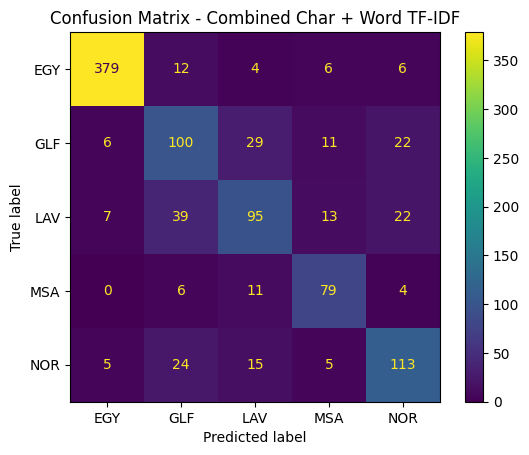

In [16]:
labels = list(model.named_steps["clf"].classes_)

cm = confusion_matrix(test_df["label"], combined_preds, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix - Combined Char + Word TF-IDF")
plt.show()

## Combined model confusion matrix interpretation

The combined character + word TF-IDF model performs very well on Egyptian Arabic and reasonably well on Modern Standard Arabic and North African Arabic. Egyptian remains the easiest class because its spelling and lexical patterns are highly distinctive.

The main errors are still between Gulf, Levantine, and North African Arabic. For example, many true Levantine examples are predicted as Gulf, and many true Gulf examples are predicted as Levantine or North African. This suggests that adding word-level features did not fully solve the hardest distinction in the dataset.

The combined model adds lexical information, but the remaining confusion shows that dialect boundaries are not always clean in short text snippets. Some dialects share vocabulary, and informal spelling can blur regional differences.